 ## **PART A**
 ##### **Step 01** : Environment Setup
 ##### **Step 02** : Load & Preview Dataset
 ##### **Step 03** : Dataset Structure Analysis
 ##### **Step 04** : Missing Values & Duplicates
 ##### **Step 05** : Descriptive Statistics

#***STEP 01***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
data = {
    "Library": ["NumPy", "Pandas", "Matplotlib", "Seaborn"],
    "Version": [
        np.__version__,
        pd.__version__,
        plt.matplotlib.__version__,
        sns.__version__
    ]
}
versions_df = pd.DataFrame(data)
versions_df

,Library,Version
0,NumPy,2.0.2
1,Pandas,2.2.2
2,Matplotlib,3.10.0
3,Seaborn,0.13.2


#***STEP 02***

In [3]:
df = pd.read_csv('StudentsPerformance.csv')

print("First 10 rows")
print(df.head(10))

print("="*60)

print("Last 5 rows")
print(df.tail(5))

print("="*60)

print("Random Sample (8 rows)")
print(df.sample(8, random_state=42))

First 10 rows
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2    

Each row represents an individual student.

Columns:
* gender: Indicates whether the student is male or female
* race/ethnicity: Categorical grouping of students into different ethnic backgrounds
* parental level of education: The highest level of education attained by the student's parents
* lunch: Type of lunch received (standard or free/reduced), which may reflect socioeconomic status
* test preparation course: Whether the student completed a test preparation course
* math score: Student's score in mathematics (0 - 100)
* reading score: Student's score in reading (0 - 100)
* writing score: Student's score in writing (0 - 100)

#***STEP 03***

In [4]:
# Shape of dataset
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\n" + "-"*50)

# Info
print("Dataset Info:")
df.info()

print("\n" + "-"*50)

# Data types of each column
print("Data Types:")
print(df.dtypes)

print("\n" + "-"*50)

# Column names
print("Column Names:")
print(df.columns.tolist())

print("\n" + "-"*50)

# Count categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns Count:", len(categorical_cols))
print("Categorical Columns:", list(categorical_cols))

print("\nNumerical Columns Count:", len(numerical_cols))
print("Numerical Columns:", list(numerical_cols))

Dataset Shape (Rows, Columns):
(1000, 8)

--------------------------------------------------
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

--------------------------------------------------
Data Types:
gender                         object
race/ethnicity                 object
parental level of education

The dataset has 1000 rows and 8 columns.

Out of these, 5 columns are categorical (gender, race/ethnicity, parental education, lunch, test preparation), and 3 columns are numerical (math, reading, and writing scores).

All columns have complete data with no missing values, and the data types look correct. The categorical columns are stored as text (object), and the score columns are stored as numbers (int64).

#### **Data Type Observation**

The data types are fine and match the type of data in each column, so no changes are needed at this stage.

#### **For Machine Learning**

Before using this data in machine learning, the categorical columns will need to be converted into numbers using encoding methods. The numerical columns can be used as they are.

#***STEP 04***

In [5]:
# Missing values count
missing = df.isnull().sum()

# Percentage of missing values
missing_percent = (missing / len(df)) * 100

print("Missing Values:\n")
print(missing)

print("\nMissing Percentage (%):\n")
print(missing_percent)

print("\n" + "="*50)

# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

Missing Values:

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Missing Percentage (%):

gender                         0.0
race/ethnicity                 0.0
parental level of education    0.0
lunch                          0.0
test preparation course        0.0
math score                     0.0
reading score                  0.0
writing score                  0.0
dtype: float64

Duplicate Rows: 0


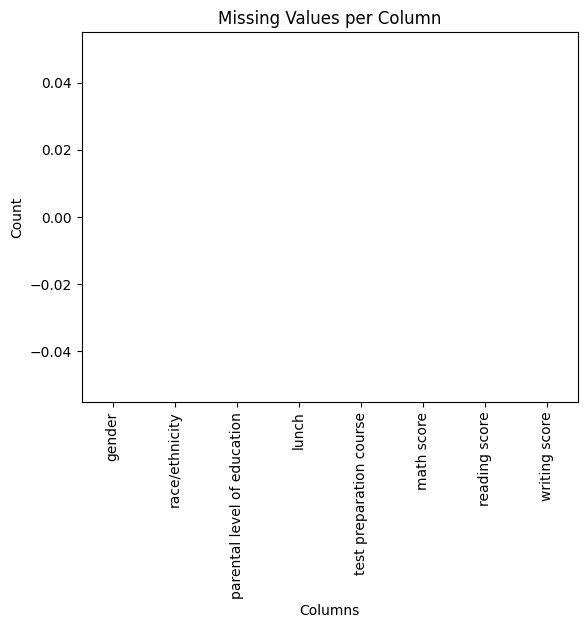

In [7]:
# bar Chart
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

The dataset does not contain any missing values, as all columns have complete data. The percentage of missing values in every column is 0%, which means the dataset is already clean and does not require any handling for missing data.

There are also no duplicate rows in the dataset, so each entry is unique. This confirms that the data quality is good.

If there were missing values, they could be handled by filling them with the mean, median, or most frequent value depending on the column, or by removing the affected rows if necessary.

#***STEP 05***

In [10]:
df.describe()

subjects = ['math score', 'reading score', 'writing score']
stats_df = pd.DataFrame()
for sub in subjects:
    stats_df.loc[sub, 'mean'] = df[sub].mean()
    stats_df.loc[sub, 'median'] = df[sub].median()
    stats_df.loc[sub, 'mode'] = df[sub].mode()[0]
    stats_df.loc[sub, 'std'] = df[sub].std()
    stats_df.loc[sub, 'variance'] = df[sub].var()
    stats_df.loc[sub, 'min'] = df[sub].min()
    stats_df.loc[sub, 'max'] = df[sub].max()
    stats_df.loc[sub, 'range'] = df[sub].max() - df[sub].min()
stats_df
stats_df.round(2)

,mean,median,mode,std,variance,min,max,range
math score,66.09,66.0,65.0,15.16,229.92,0.0,100.0,100.0
reading score,69.17,70.0,72.0,14.60,213.17,17.0,100.0,83.0
writing score,68.05,69.0,74.0,15.20,230.91,10.0,100.0,90.0


From the table, the reading score has the highest average, followed by writing and then math. This shows that students generally perform better in reading compared to the other subjects.

The math score has the highest variability (standard deviation), which means student performance in math is more spread out. Some students score very high while others score much lower.

This suggests that math might be more difficult or inconsistent for students, while reading and writing are relatively more stable subjects with less variation in scores.

## **Part B**

##### **Step 06** : Categorical Distribution Analysis
##### **Step 07** : Group Mean Score Comparisons
##### **Step 08** : Correlation Analysis & Heatmap
##### **Step 09** : Test Prep Impact Analysis
##### **Step 10** : Gender Score Deep-Dive

#***STEP 06***

In [12]:
categorical_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in categorical_cols:
    print(f"\nValue Counts for {col}")
    print(df[col].value_counts())

    print(f"\nPercentage (%) for {col}")
    print(df[col].value_counts(normalize=True) * 100)

    print("\n" + "-"*50)


Value Counts for gender
gender
female    518
male      482
Name: count, dtype: int64

Percentage (%) for gender
gender
female    51.8
male      48.2
Name: proportion, dtype: float64

--------------------------------------------------

Value Counts for race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Percentage (%) for race/ethnicity
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64

--------------------------------------------------

Value Counts for parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Percentage (%) for parental level of education
parental level of education
some college          22.6
associate's degree    22.2
high school    

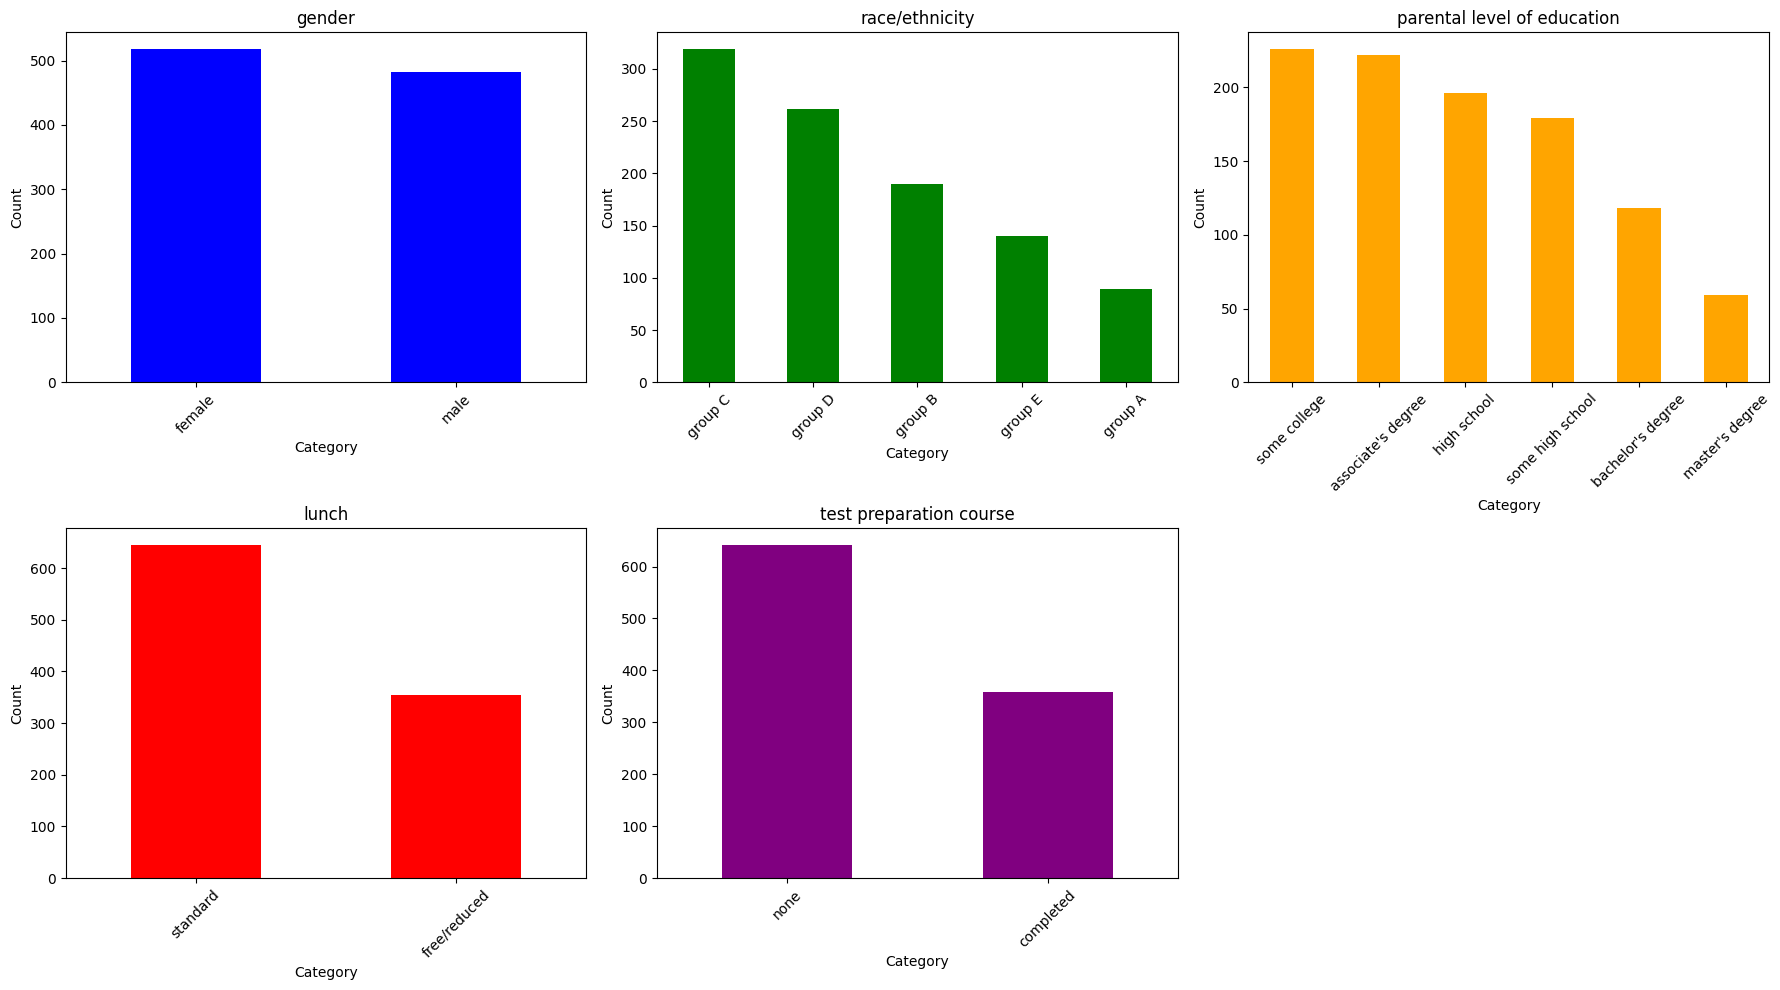

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['blue', 'green', 'orange', 'red', 'purple']

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Hide the empty 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

From the data, around 36% of students completed the test preparation course, while the majority did not complete it.

The most common parental education level is some college, which has the highest number of students compared to other categories.

This shows that most students did not take test preparation, and a large number come from a similar parental education background.

#***STEP 07***

In [16]:
group_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

score_cols = ['math score', 'reading score', 'writing score']

for col in group_cols:
    print(f"\nAverage scores by {col}:\n")
    display(df.groupby(col)[score_cols].mean().round(2))
    print("-"*50)


Average scores by gender:



,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


--------------------------------------------------

Average scores by race/ethnicity:



,math score,reading score,writing score
race/ethnicity,,,
group A,61.63,64.67,62.67
group B,63.45,67.35,65.60
group C,64.46,69.10,67.83
group D,67.36,70.03,70.15
group E,73.82,73.03,71.41


--------------------------------------------------

Average scores by parental level of education:



...

--------------------------------------------------

Average scores by lunch:



,math score,reading score,writing score
lunch,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


--------------------------------------------------

Average scores by test preparation course:



,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


--------------------------------------------------


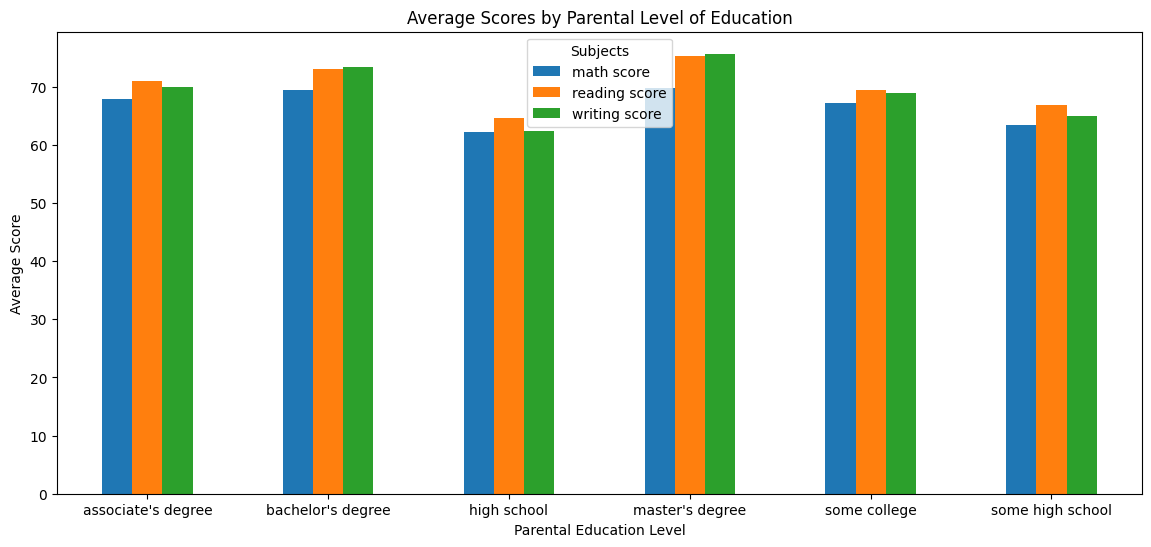

In [19]:
edu_scores = df.groupby('parental level of education')[score_cols].mean().round(2)

edu_scores.plot(kind='bar', figsize=(14,6))

plt.title("Average Scores by Parental Level of Education")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")

plt.show()

From the grouped results, students whose parents have higher education levels tend to score better across all subjects.

For example, students whose parents have a master's degree have average scores of around 70+ in math and mid-70s in reading and writing, which are higher compared to students whose parents have only high school education, where scores are generally lower (around mid-60s).

This shows a clear pattern that parental education has a positive impact on student performance, as higher parental education is associated with higher average scores.

#***STEP 08***

In [20]:
score_cols = ['math score', 'reading score', 'writing score']

corr_matrix = df[score_cols].corr()

print("Correlation Matrix:\n")
print(corr_matrix)

Correlation Matrix:

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


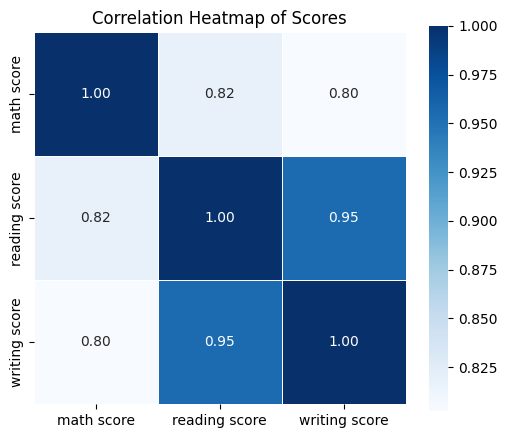

In [21]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Scores")
plt.show()

In [22]:
math_reading_corr = df['math score'].corr(df['reading score'])
reading_writing_corr = df['reading score'].corr(df['writing score'])

print("Math vs Reading Correlation:", round(math_reading_corr, 2))
print("Reading vs Writing Correlation:", round(reading_writing_corr, 2))

Math vs Reading Correlation: 0.82
Reading vs Writing Correlation: 0.95


From the correlation matrix, all three subjects are positively correlated, meaning students who perform well in one subject tend to perform well in others.

The strongest correlation is between reading and writing scores, which is very high (close to 0.95 or above). This shows that students who are good at reading are usually also good at writing.

The correlation between math and reading is also positive but slightly lower, indicating that these skills are related but not as strongly connected.

From an educational perspective, this suggests that reading and writing skills are closely linked, while math performance depends on somewhat different abilities. Improving reading skills may also help improve writing performance.

#***STEP 09***

In [24]:
score_cols = ['math score', 'reading score', 'writing score']
group_stats = df.groupby('test preparation course')[score_cols].agg(['mean', 'std']).round(2)

group_stats

math score        reading score        writing score  \
                              mean    std          mean    std          mean   
test preparation course                                                        
completed                    69.70  14.44         73.89  13.64         74.42   
none                         64.08  15.19         66.53  14.46         64.50   

                                
                           std  
test preparation course         
completed                13.38  
none                     15.00

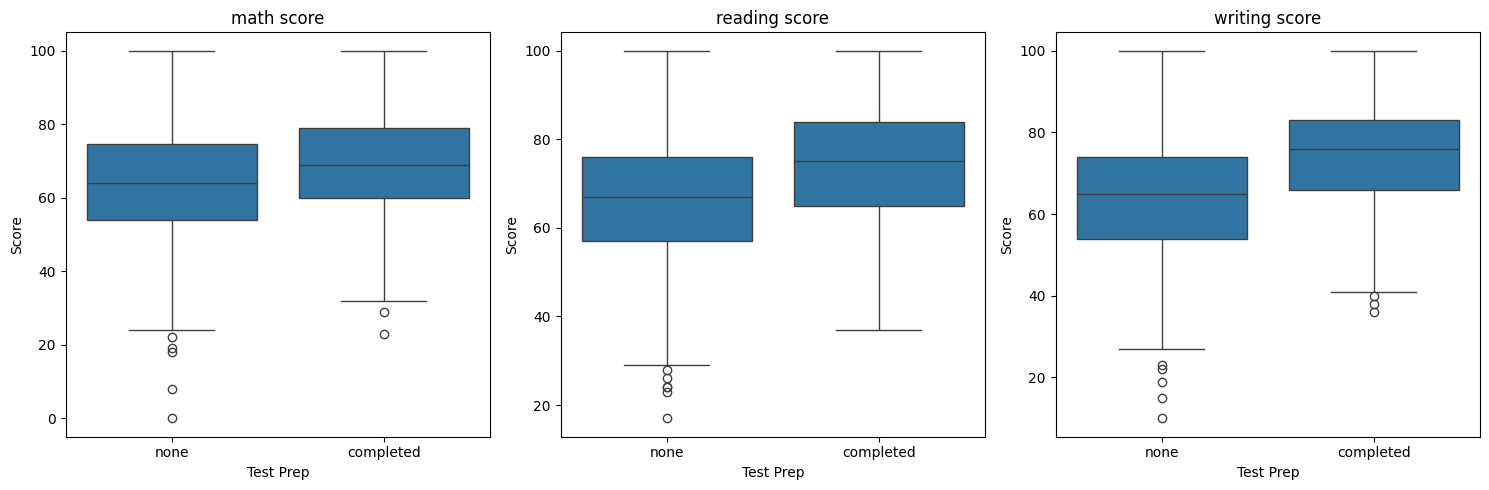

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(score_cols):
    sns.boxplot(
        x='test preparation course',
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Test Prep")
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [26]:
completed = df[df['test preparation course'] == 'completed'][score_cols].mean()
none = df[df['test preparation course'] == 'none'][score_cols].mean()

improvement = ((completed - none) / none) * 100

improvement.round(2)

,0
math score,8.77
reading score,11.06
writing score,15.37


The improvement is visible across all subjects, but the highest improvement is seen in writing and reading scores, where the percentage increase is greater than in math. This shows that test preparation has a stronger effect on language-based subjects.

Math scores also improve, but the increase is slightly smaller compared to reading and writing.

Based on these results, the test preparation program appears to be effective, and it would be recommended as it helps improve student performance, especially in reading and writing.

#***STEP 10***

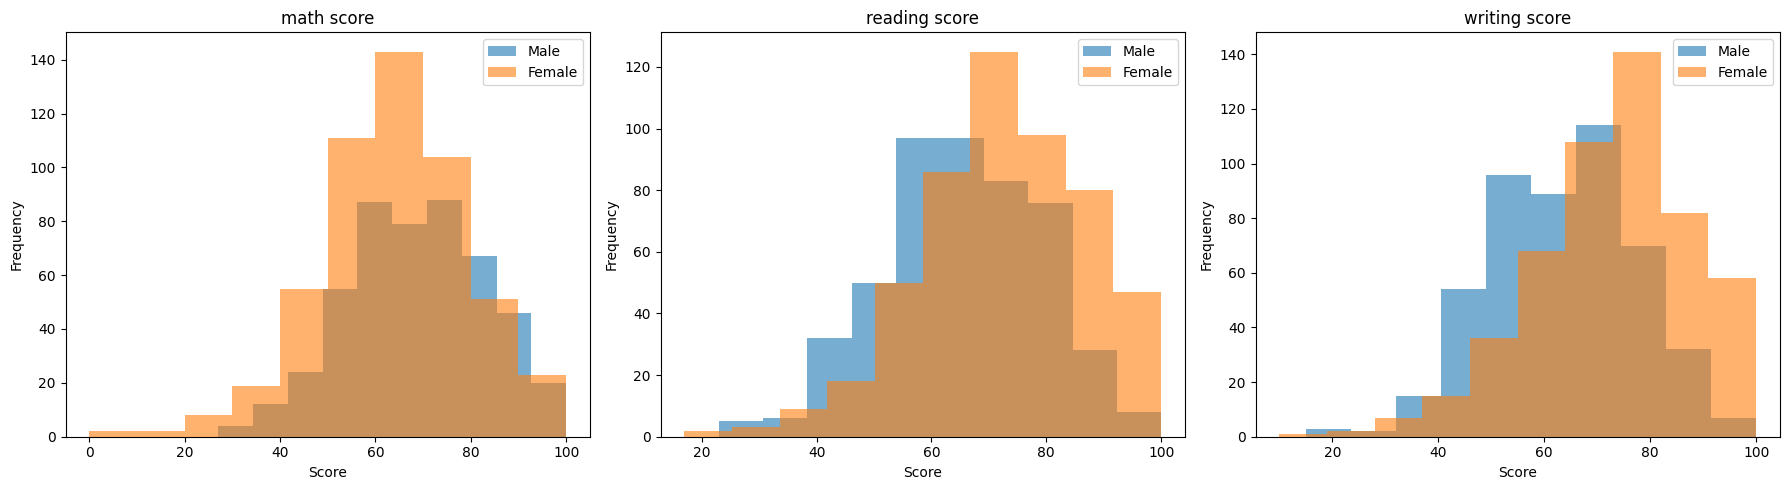

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

subjects = ['math score', 'reading score', 'writing score']
for i, sub in enumerate(subjects):
    # Male
    df[df['gender'] == 'male'][sub].plot(
        kind='hist',
        alpha=0.6,
        ax=axes[i],
        label='Male'
    )
    # Female
    df[df['gender'] == 'female'][sub].plot(
        kind='hist',
        alpha=0.6,
        ax=axes[i],
        label='Female'
    )
    axes[i].set_title(sub)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [28]:
results = pd.DataFrame()

for sub in subjects:
    male_pct = (df[df['gender'] == 'male'][sub] > 70).mean() * 100
    female_pct = (df[df['gender'] == 'female'][sub] > 70).mean() * 100

    results.loc[sub, 'Male (%)'] = male_pct
    results.loc[sub, 'Female (%)'] = female_pct

results.round(2)

,Male (%),Female (%)
math score,45.85,32.82
reading score,38.38,58.30
writing score,32.16,58.11


From the results, female students clearly perform better than male students in reading and writing. Around 58% of females score above 70 in both reading and writing, compared to only about 38% (reading) and 32% (writing) for males.

This suggests that females tend to have stronger performance in language-based subjects, while males perform better in math.

These differences may be due to variations in interests, learning styles, or study habits between genders.

## **Part C**

##### **Step 11** : Feature Engineering
##### **Step 12** : Pair Plot Multi-Variable Analysis
##### **Step 13** : Pivot Tables & Advanced Grouping
##### **Step 14** : Write 3 Reusable Python Functions
##### **Step 15** : NumPy Manual Statistical Computations

#***STEP 11***

In [29]:
# Total score
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

# Average score
df['average_score'] = df['total_score'] / 3

# Performance grade
def assign_grade(avg):
    if avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['performance_grade'] = df['average_score'].apply(assign_grade)

# High achiever
df['high_achiever'] = df['average_score'] >= 80

# Lowest subject
df['lowest_subject'] = df[['math score', 'reading score', 'writing score']].idxmin(axis=1)

In [30]:
df.head(10)
print("Grade Distribution:\n")
print(df['performance_grade'].value_counts())

print("\nLowest Subject Distribution:\n")
print(df['lowest_subject'].value_counts())

Grade Distribution:

performance_grade
B    261
C    256
A    198
D    182
F    103
Name: count, dtype: int64

Lowest Subject Distribution:

lowest_subject
math score       552
writing score    292
reading score    156
Name: count, dtype: int64


The total_score combines all three subjects to give an overall score for each student, while average_score provides a normalized measure of performance.

The performance_grade categorizes students into grades (A-F) based on their average score, making it easier to compare performance levels.

The high_achiever column identifies students with strong performance (average ≥ 80), which helps in filtering top students.

Finally, the lowest_subject column shows the subject where each student scored the least, helping to identify weak areas.

#***STEP 12***

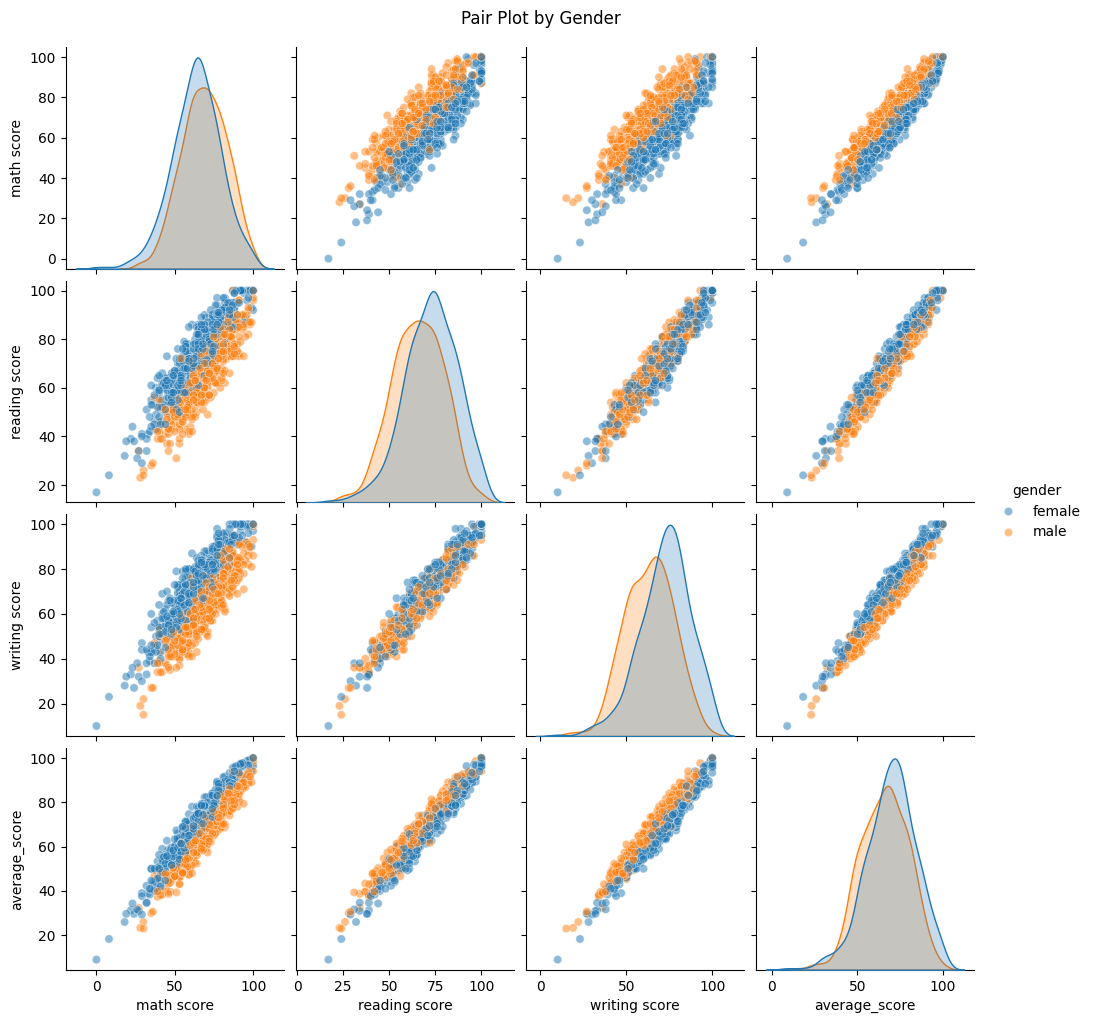

In [31]:
cols = ['math score', 'reading score', 'writing score', 'average_score']
pairplot1 = sns.pairplot(
    df[cols + ['gender']],
    hue='gender',
    plot_kws=dict(alpha=0.5)
)
pairplot1.fig.suptitle("Pair Plot by Gender", y=1.02)

# Save image
pairplot1.savefig("pairplot_scores.png", dpi=150)
plt.show()

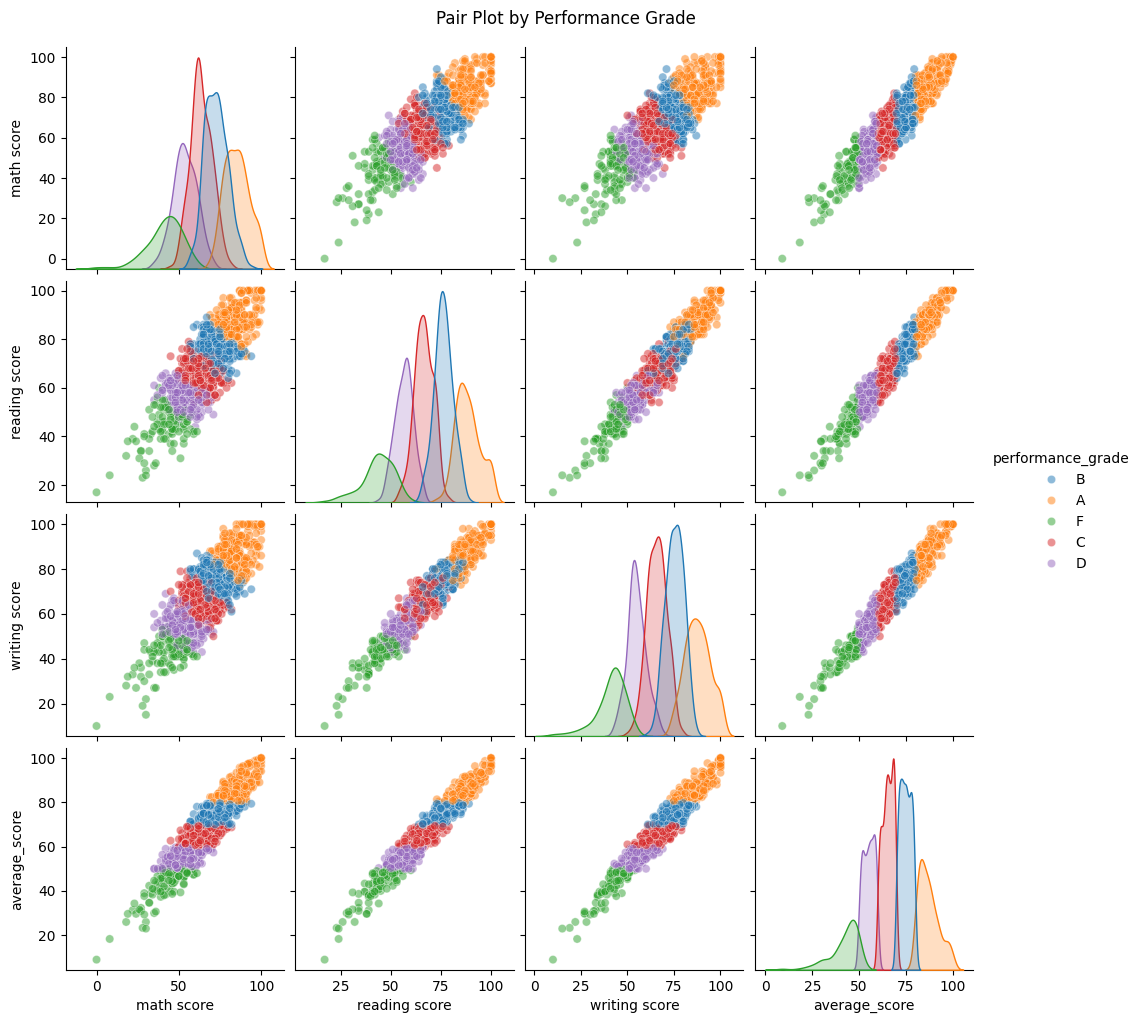

In [32]:
pairplot2 = sns.pairplot(
    df[cols + ['performance_grade']],
    hue='performance_grade',
    plot_kws=dict(alpha=0.5)
)
pairplot2.fig.suptitle("Pair Plot by Performance Grade", y=1.02)

# Save image
pairplot2.savefig("pairplot_grades.png", dpi=150)

plt.show()

From the pair plots, the classes are partially separable. There is some overlap between groups, especially when comparing gender, where male and female data points are mixed across most plots.

However, when colored by performance grade, the separation is more visible. Students with higher grades tend to cluster in higher score regions, while lower grades appear in lower score ranges.

This suggests that a classifier may perform reasonably well when predicting performance grades, since there is some pattern in the data. However, due to overlap between classes, the model may not be perfectly accurate.

#***STEP 13***

In [33]:
pivot1 = pd.pivot_table(
    df,
    values='average_score',
    index='parental level of education',
    columns='gender',
    aggfunc='mean'
).round(2)

pivot1

gender,female,male
parental level of education,,
associate's degree,71.12,67.87
bachelor's degree,74.67,68.78
high school,64.75,61.58
master's degree,73.65,73.52
some college,71.00,65.72
some high school,65.56,64.64


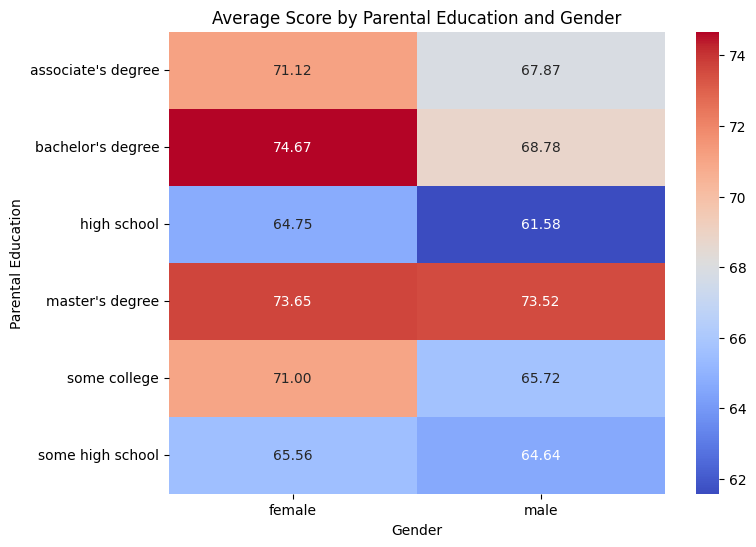

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot1,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title("Average Score by Parental Education and Gender")
plt.xlabel("Gender")
plt.ylabel("Parental Education")

plt.show()

In [35]:
pivot2 = pd.pivot_table(
    df,
    values='math score',
    index='race/ethnicity',
    columns='test preparation course',
    aggfunc='mean'
).round(2)

pivot2

test preparation course,completed,none
race/ethnicity,,
group A,68.26,58.09
group B,67.19,61.37
group C,67.50,62.71
group D,69.79,66.26
group E,77.43,71.11


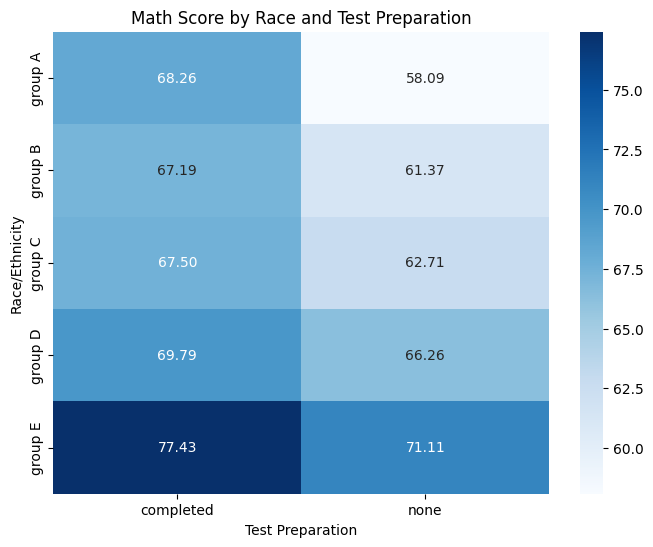

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot2,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title("Math Score by Race and Test Preparation")
plt.xlabel("Test Preparation")
plt.ylabel("Race/Ethnicity")

plt.show()

From the first pivot table, the gender gap in scores varies across different parental education levels. In most cases, female students have slightly higher average scores than male students, especially when parental education is higher.

The difference between male and female scores is not the same across all education levels. In some groups, the gap is small, while in others it becomes more noticeable.

This suggests that parental education not only affects overall performance but also influences how the gender gap appears. Higher parental education levels are generally associated with better scores for both genders, but females often maintain a slight advantage.

#***STEP 14***

In [42]:
def score_summary(df, col):
    """
    Returns summary statistics for a given column:
    mean, median, std, min, max, and percentage above 70.
    """
    data = df[col]

    summary = {
        'mean': data.mean(),
        'median': data.median(),
        'std': data.std(),
        'min': data.min(),
        'max': data.max(),
        'pct_above_70': (data > 70).mean() * 100
    }

    return summary

In [45]:
score_summary(df, 'math score')

{'mean': np.float64(66.089),
 'median': 66.0,
 'std': 15.163080096009468,
 'min': 0,
 'max': 100,
 'pct_above_70': np.float64(39.1)}

In [43]:
def plot_distribution(df, col, color):
    """
    Plots histogram with KDE curve and mean line for a given column.
    """
    data = df[col]

    plt.figure(figsize=(6,4))

    sns.histplot(data, kde=True, color=color)

    mean_val = data.mean()
    plt.axvline(mean_val, color='black', linestyle='--', label=f"Mean = {mean_val:.2f}")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

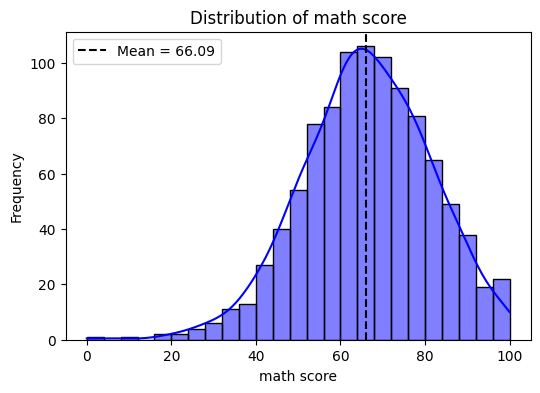

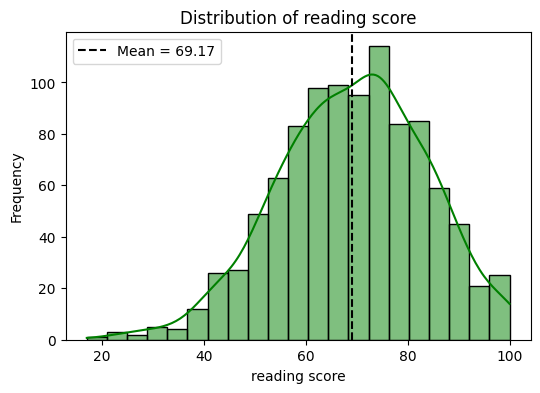

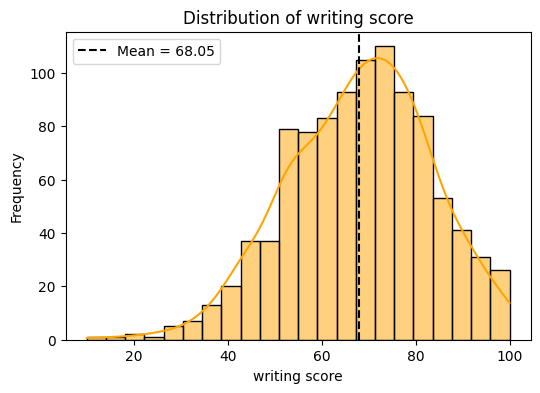

In [46]:
plot_distribution(df, 'math score', 'blue')
plot_distribution(df, 'reading score', 'green')
plot_distribution(df, 'writing score', 'orange')

In [44]:
def compare_groups(df, group_col, score_col):
    """
    Returns a sorted DataFrame of group means and percentage above 70.
    """
    grouped = df.groupby(group_col)[score_col]

    result = pd.DataFrame({
        'mean_score': grouped.mean(),
        'pct_above_70': grouped.apply(lambda x: (x > 70).mean() * 100)
    })

    return result.sort_values(by='mean_score', ascending=False)

In [47]:
compare_groups(df, 'gender', 'math score')
compare_groups(df, 'test preparation course', 'reading score')

,mean_score,pct_above_70
test preparation course,,
completed,73.893855,62.569832
none,66.534268,40.965732


#***STEP 15***

In [48]:
math = df['math score'].values
reading = df['reading score'].values
writing = df['writing score'].values

def numpy_stats(arr):
    return {
        'mean': np.mean(arr),
        'median': np.median(arr),
        'std': np.std(arr),
        'var': np.var(arr),
        'min': np.min(arr),
        'max': np.max(arr)
    }

print("Math Stats:", numpy_stats(math))
print("Reading Stats:", numpy_stats(reading))
print("Writing Stats:", numpy_stats(writing))

Math Stats: {'mean': np.float64(66.089), 'median': np.float64(66.0), 'std': np.float64(15.155496659628149), 'var': np.float64(229.68907899999996), 'min': np.int64(0), 'max': np.int64(100)}
Reading Stats: {'mean': np.float64(69.169), 'median': np.float64(70.0), 'std': np.float64(14.592890015346516), 'var': np.float64(212.95243900000003), 'min': np.int64(17), 'max': np.int64(100)}
Writing Stats: {'mean': np.float64(68.054), 'median': np.float64(69.0), 'std': np.float64(15.188057281956768), 'var': np.float64(230.677084), 'min': np.int64(10), 'max': np.int64(100)}


In [49]:
def z_score_analysis(arr):
    z = (arr - np.mean(arr)) / np.std(arr)
    high = np.sum(z > 2)
    low = np.sum(z < -2)
    return high, low

print("Math Z-score:", z_score_analysis(math))
print("Reading Z-score:", z_score_analysis(reading))
print("Writing Z-score:", z_score_analysis(writing))

Math Z-score: (np.int64(19), np.int64(27))
Reading Z-score: (np.int64(20), np.int64(26))
Writing Z-score: (np.int64(18), np.int64(24))


In [50]:
percentiles = [10, 25, 50, 75, 90]

table = np.array([
    np.percentile(math, percentiles),
    np.percentile(reading, percentiles),
    np.percentile(writing, percentiles)
])

table

array([[47.  , 57.  , 66.  , 77.  , 86.  ],
       [51.  , 59.  , 70.  , 79.  , 87.1 ],
       [48.  , 57.75, 69.  , 79.  , 87.  ]])

In [51]:
top10_idx = np.argsort(math)[-10:][::-1]
top10_idx

array([916, 458, 962, 625, 623, 451, 149, 306, 114, 263])

In [52]:
def pass_rate(arr):
    return np.mean(arr > 70) * 100

print("Math Pass Rate:", pass_rate(math))
print("Reading Pass Rate:", pass_rate(reading))
print("Writing Pass Rate:", pass_rate(writing))

Math Pass Rate: 39.1
Reading Pass Rate: 48.699999999999996
Writing Pass Rate: 45.6


The results show that reading and writing have slightly higher average scores than math, which means students generally perform better in these subjects.

From the Z-score analysis, only a small number of students fall above +2 or below -2, indicating that very few students have extremely high or extremely low scores. Most students are clustered around the average.

The percentile results show a smooth distribution of scores, where values increase gradually from the 10th to the 90th percentile. This suggests that the data is fairly well spread without any unusual gaps.

Using np.argsort(), the top 10 math scorers were identified by their indices, which helps in ranking students based on performance.

The pass rate (scores above 70) is highest in reading and writing, while math has a lower pass rate, indicating that math is relatively more challenging for students

#***STEP 16***

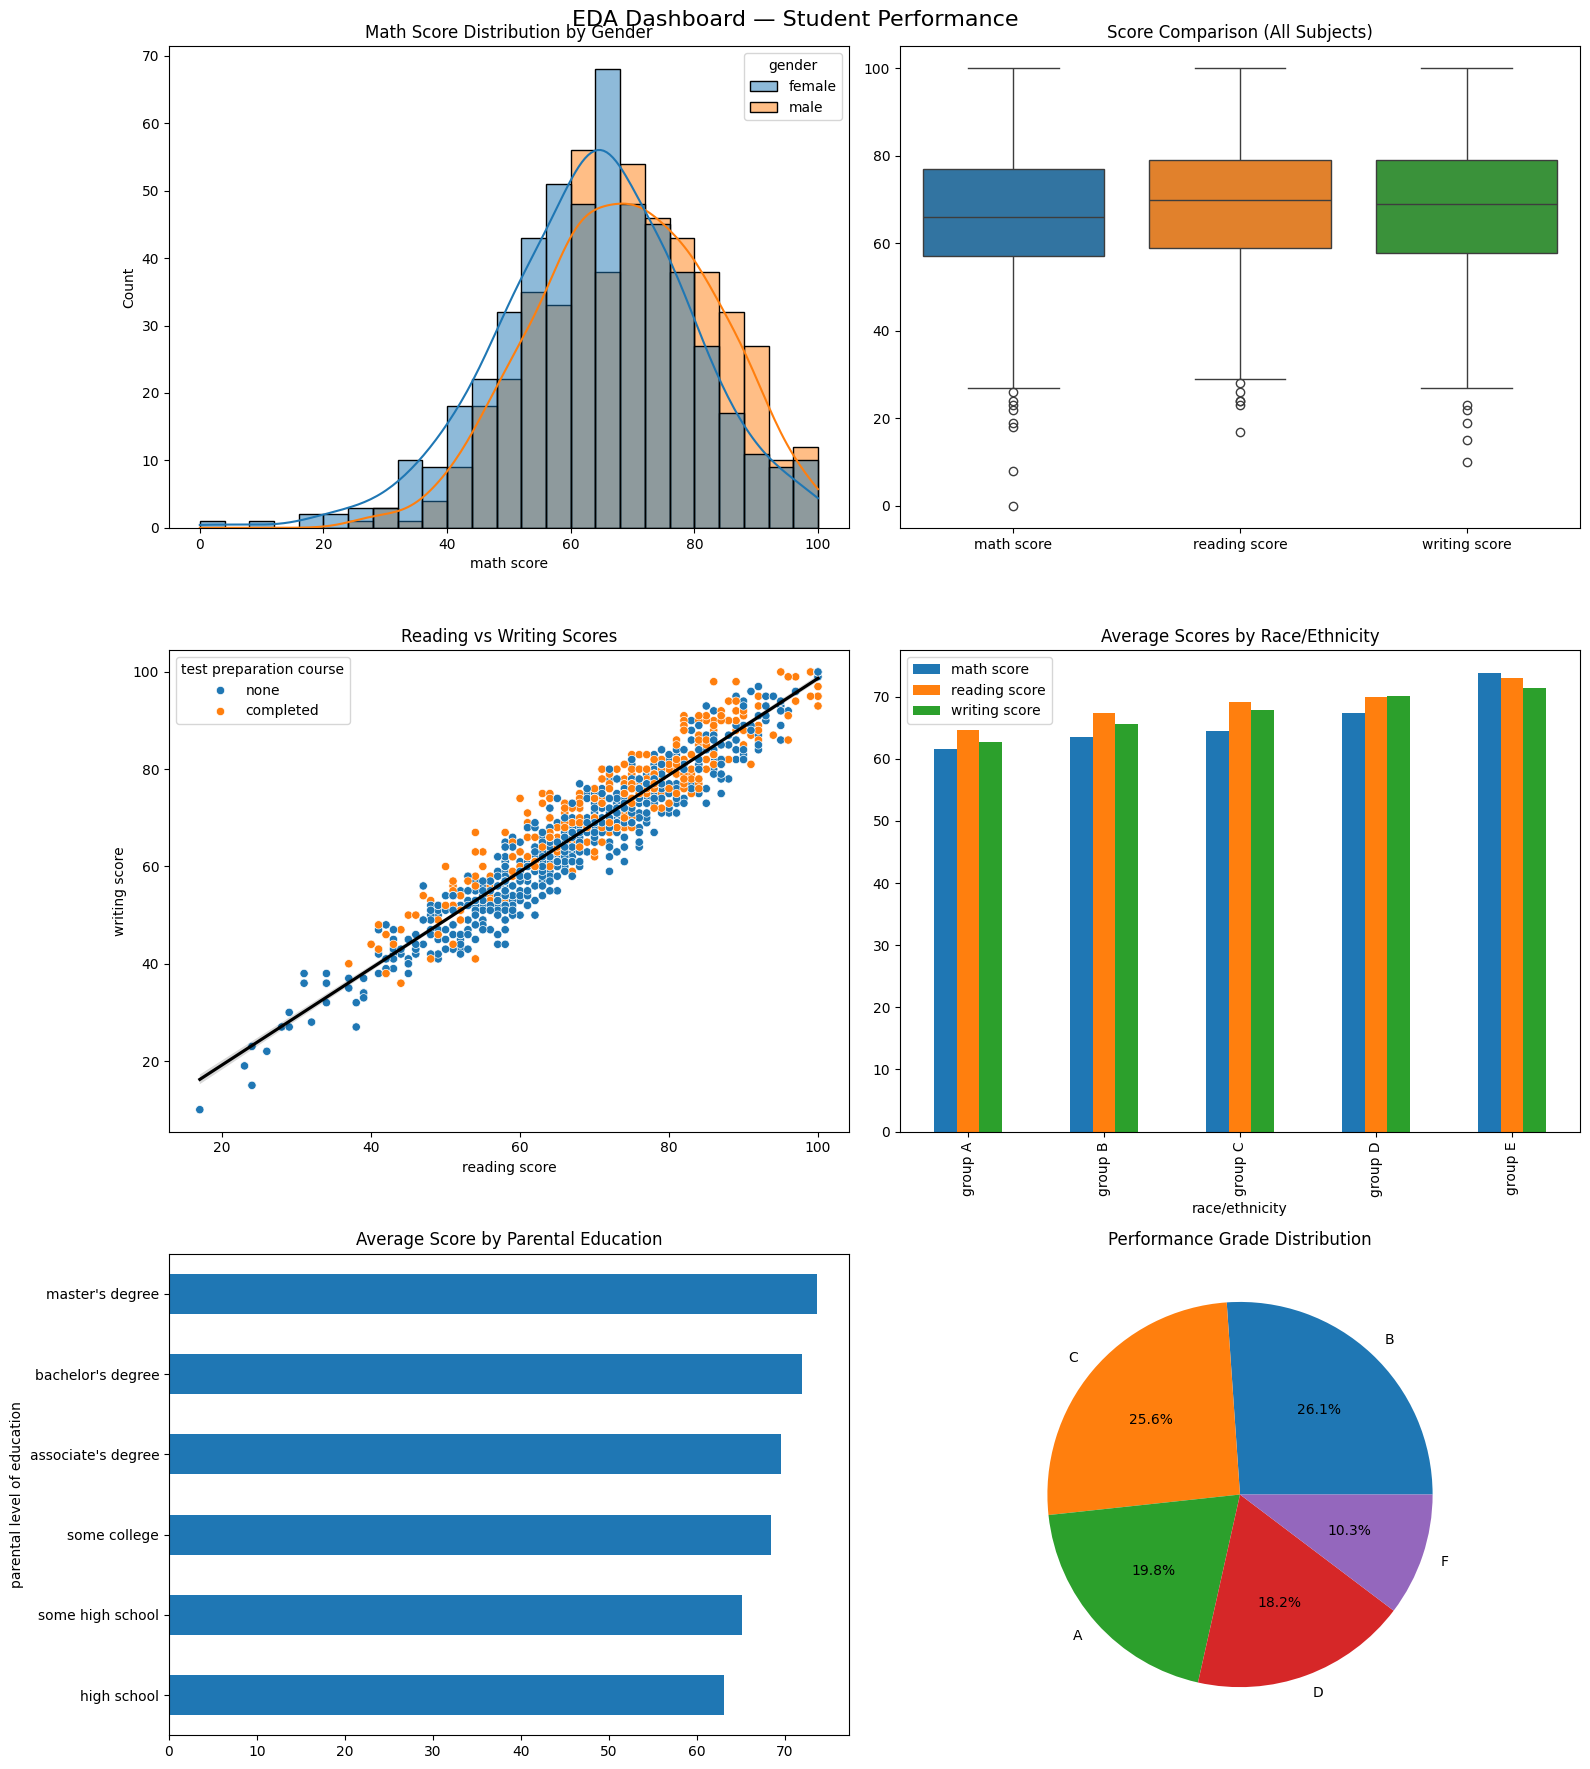

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Flatten axes for easy use
axes = axes.flatten()

# 1. Math score histogram with KDE (by gender)
sns.histplot(data=df, x='math score', hue='gender', kde=True, ax=axes[0])
axes[0].set_title("Math Score Distribution by Gender")

# 2. Box plot (all 3 subjects)
sns.boxplot(data=df[['math score', 'reading score', 'writing score']], ax=axes[1])
axes[1].set_title("Score Comparison (All Subjects)")

# 3. Scatter plot (reading vs writing, with regression, colored by test prep)
sns.scatterplot(
    data=df,
    x='reading score',
    y='writing score',
    hue='test preparation course',
    ax=axes[2]
)
sns.regplot(
    data=df,
    x='reading score',
    y='writing score',
    scatter=False,
    ax=axes[2],
    color='black'
)
axes[2].set_title("Reading vs Writing Scores")

# 4. Grouped bar chart (race vs subjects)
race_scores = df.groupby('race/ethnicity')[['math score','reading score','writing score']].mean()
race_scores.plot(kind='bar', ax=axes[3])
axes[3].set_title("Average Scores by Race/Ethnicity")

# 5. Horizontal bar (parental education sorted)
edu_scores = df.groupby('parental level of education')['average_score'].mean().sort_values()
edu_scores.plot(kind='barh', ax=axes[4])
axes[4].set_title("Average Score by Parental Education")

# 6. Pie chart (grade distribution)
grade_counts = df['performance_grade'].value_counts()
axes[5].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
axes[5].set_title("Performance Grade Distribution")

# Super title
plt.suptitle("EDA Dashboard — Student Performance", fontsize=16)

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=150)

plt.show()

#***STEP 17***

### **1. Executive Summary**

This analysis explores student performance based on various factors such as gender, parental education, test preparation, and subject scores. The goal was to understand patterns in academic performance and identify factors that influence results. Overall, students performed better in reading and writing compared to math. Test preparation showed a clear positive impact on performance, especially in language-based subjects. Gender differences were also observed, with females performing better in reading and writing, while males showed slightly better performance in math. The analysis highlights important relationships in the data that can help improve student outcomes.

### **2. Data Quality Assessment**

The dataset is clean and well-structured, containing 1000 rows and 8 columns. There are no missing values in any of the columns, and no duplicate records were found. All data types are appropriate, with categorical variables stored as text and score-related columns stored as numerical values. This makes the dataset ready for analysis without requiring major preprocessing. Since there are no inconsistencies or errors, the data quality is reliable and suitable for both statistical analysis and machine learning tasks.

### **3. Key Statistical Findings**

The statistical analysis shows that reading and writing scores have higher averages compared to math, indicating that students generally perform better in these subjects. Math scores also show higher variability, suggesting that student performance in math is more spread out. Group comparisons reveal that students who completed the test preparation course scored higher across all subjects. Additionally, students with higher parental education levels tend to achieve better scores. Gender-based analysis shows that females outperform males in reading and writing, while males perform slightly better in math. These findings highlight clear patterns in student performance across different groups.

### **4. Visualization Insights**

The visualizations provide clear insights into the data. Histograms show that score distributions are fairly normal, with most students scoring around the middle range. Box plots highlight differences in subject performance, especially showing that math has more variation. Scatter plots reveal a strong positive relationship between reading and writing scores. The grouped bar charts and heatmaps show that parental education and test preparation both have a noticeable impact on performance. The dashboard combines all key insights, making it easy to understand patterns and trends visually.

### **5. Feature Engineering Rationale**

New features were created to better represent student performance. The total score and average score combine all subjects into a single measure, making it easier to compare students. The performance grade categorizes students into levels based on their average score, which simplifies analysis. The high achiever column helps identify top-performing students, while the lowest subject highlights areas where students struggle the most. These features improve the dataset and make it more useful for further analysis and machine learning.

### **6. Actionable Recommendations for Educators**

Based on the analysis, educators should encourage students to complete test preparation programs, as they clearly improve performance. Special attention should be given to math, as it appears to be the most challenging subject for many students. Schools can provide additional support such as tutoring or practice sessions for math. Since parental education is linked to student performance, schools should also provide extra academic support to students from less educated family backgrounds. Focusing on reading and writing skills can further enhance overall academic performance, as these subjects are strongly related.

### **7. Reflection & Lessons Learned**

This project helped in understanding how to analyze real-world data using Python. It improved skills in data cleaning, visualization, and statistical analysis. Working with libraries like NumPy, Pandas, and Seaborn made it easier to explore and understand patterns in the data. One important lesson learned is that small factors like test preparation and parental education can have a significant impact on performance. Overall, this task provided practical experience in data analysis and helped build a strong foundation for future machine learning projects.